# India Tourism Data Analysis & Econometric Pipeline (2022–2026)
This notebook provides an end-to-end data science and econometric pipeline for the official India Tourism datasets (updated with 2025–2026 data).

### Pipeline Structure:
1. **Data Ingestion**: Import all 8 official datasets.
2. **Data Inspection & Description**: Detailed schema overview, column types, and statistical summaries before optimization.
3. **DataType Optimization (Individual Cells)**: Casting each dataset into memory-efficient, analysis-ready types (`Int64`, `category`, `string`, `datetime`).
4. **Domain-Aware Missing Value Imputation (Individual Cells)**: Structural zeros, rounded group medians, and explicit category tokens.
5. **Feature Engineering (Individual Cells)**: Deriving domain indicators (foreign visitor share, hotel density, spending velocity, NPS sentiment, airport loads).
6. **Relational Merge**: Building the 2026 Unified District Master Dataset (`df_district_master`).
7. **Targeted Analytical Queries (Individual Cells)**: Answering core policy and business questions.
8. **Standalone Visualizations (Individual Cells)**: Uncluttered, spacious charts for seasonality, spend vs experience, rankings, and correlations.


In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings for clean tabular viewing
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
sns.set_theme(style='whitegrid', font_scale=1.0)
print(f'Environment Ready. Pandas version: {pd.__version__}')


Environment Ready. Pandas version: 3.0.3


## 1. Import All 8 Datasets (Updated through 2026)
Loading all official datasets into dedicated Pandas DataFrames.


In [106]:
# 1. District-wise tourist footfall (2022-2026)
df_district_footfall = pd.read_csv('../data/raw/01_district_wise_tourist_footfall_2022_2024.csv')

# 2. NIDHI hospitality establishments registry (audits through 2026)
df_nidhi_hospitality = pd.read_csv('../data/raw/02_nidhi_hospitality_establishments_registry.csv')

# 3. ASI centrally protected monuments inventory (footfalls through 2026)
df_asi_monuments = pd.read_csv('../data/raw/03_asi_protected_monuments_inventory.csv')

# 4. Inbound tourist exit survey microdata (2023-2026)
df_inbound_survey = pd.read_csv('../data/raw/04_inbound_tourist_survey_microdata_2023_2024.csv')

# 5. Airport monthly passenger traffic (2022-2026)
df_airport_traffic = pd.read_csv('../data/raw/05_airport_passenger_traffic_monthly_2022_2024.csv')

# 6. Annual macro overview (2022-2026)
df_macro_overview = pd.read_csv('../data/raw/06_annual_macro_overview_2022_2024.csv')

# 7. Country-wise FTA summary (2022-2026)
df_fta_summary = pd.read_csv('../data/raw/07_country_wise_fta_summary_2022_2024.csv')

# 8. State and UT consolidated summary (2022-2026)
df_state_ut_summary = pd.read_csv('../data/raw/08_state_ut_consolidated_summary_2022_2023.csv')

print('Successfully imported all 8 datasets into DataFrames!')


Successfully imported all 8 datasets into DataFrames!


## 2. Data Inspection & Description (Before Optimization)
Before modifying or optimizing data types, this section inspects:
* Dimensions and missing value ratios across all 8 datasets.
* Exact column names, current data types, null counts, and sample entries.
* Five-point statistical summaries (`.describe()`) of initial numerical attributes.


In [107]:
# 2.1 Overview of Dataset Dimensions and Missingness
raw_datasets = {
    '01. District Footfall (2022-2026)': df_district_footfall,
    '02. NIDHI Hospitality Registry': df_nidhi_hospitality,
    '03. ASI Monuments Inventory': df_asi_monuments,
    '04. Inbound Tourist Survey (2023-2026)': df_inbound_survey,
    '05. Airport Passenger Traffic (2022-2026)': df_airport_traffic,
    '06. Annual Macro Overview (2022-2026)': df_macro_overview,
    '07. Country-wise FTA Summary': df_fta_summary,
    '08. State/UT Summary (2022-2026)': df_state_ut_summary,
}

summary_df = pd.DataFrame([
    {
        'Dataset': name,
        'Total Rows': len(df),
        'Total Columns': len(df.columns),
        'Total Nulls': df.isnull().sum().sum(),
        'Missing %': f'{(df.isnull().sum().sum() / df.size) * 100:.2f}%'
    }
    for name, df in raw_datasets.items()
])

print('--- Dataset Dimensions & Null Summary ---')
display(summary_df.head(8))


--- Dataset Dimensions & Null Summary ---


,Dataset,Total Rows,Total Columns,Total Nulls,Missing %
0,01. District Footfall (2022-2026),2380,11,1372,5.24%
1,02. NIDHI Hospitality Registry,1650,15,1868,7.55%
2,03. ASI Monuments Inventory,1200,16,3057,15.92%
3,04. Inbound Tourist Survey (2023-2026),2500,18,1353,3.01%
4,05. Airport Passenger Traffic (2022-2026),2400,14,2056,6.12%
5,06. Annual Macro Overview (2022-2026),5,9,1,2.22%
6,07. Country-wise FTA Summary,31,13,11,2.73%
7,08. State/UT Summary (2022-2026),36,18,0,0.00%


In [108]:
# 2.2 Detailed Column Schema & Type Inspection Function
def inspect_columns(df, df_name):
    schema_df = pd.DataFrame({
        'Column': df.columns,
        'Current_Dtype': [str(df[col].dtype) for col in df.columns],
        'Null_Count': [df[col].isnull().sum() for col in df.columns],
        'Null_Pct': [f'{(df[col].isnull().sum() / len(df)) * 100:.1f}%' for col in df.columns],
        'Sample_Value': [df[col].dropna().iloc[0] if not df[col].dropna().empty else None for col in df.columns]
    })
    print(f'=== Schema Inspection: {df_name} ===')
    display(schema_df.head(len(df.columns)))

# Inspect primary datasets
inspect_columns(df_district_footfall, 'df_district_footfall')
inspect_columns(df_nidhi_hospitality, 'df_nidhi_hospitality')
inspect_columns(df_inbound_survey, 'df_inbound_survey')
inspect_columns(df_asi_monuments, 'ASI Monuments Inventory	')
inspect_columns(df_airport_traffic, 'Airport Passenger Traffic (2022-2026)')
inspect_columns(df_macro_overview, ' Annual Macro Overview (2022-2026)')
inspect_columns(df_fta_summary, 'Country-wise FTA Summary')
inspect_columns(df_state_ut_summary, 'State/UT Summary (2022-2026)')



=== Schema Inspection: df_district_footfall ===


,Column,Current_Dtype,Null_Count,Null_Pct,Sample_Value
0,District,str,0,0.0%,Agra
1,State_UT,str,0,0.0%,Uttar Pradesh
2,Year,int64,0,0.0%,2022
3,Domestic_Visitors,int64,0,0.0%,2133912
4,Foreign_Visitors,float64,453,19.0%,48112.0
5,Total_Visitors,int64,0,0.0%,2182024
6,Tourism_Category,str,0,0.0%,Business_Urban
7,Registered_Hotels_Count,float64,415,17.4%,401.0
8,Avg_Stay_Duration_Days,float64,210,8.8%,3.6
9,Tourist_Police_Station_Available,str,0,0.0%,Yes


=== Schema Inspection: df_nidhi_hospitality ===


,Column,Current_Dtype,Null_Count,Null_Pct,Sample_Value
0,Establishment_ID,str,0,0.0%,NIDHI-IND-00001
1,Establishment_Name,str,0,0.0%,Heritage Chandigarh Suites
2,Accommodation_Type,str,0,0.0%,Guest House
3,Star_Classification,str,370,22.4%,Unclassified
4,State_UT,str,0,0.0%,Chandigarh
5,District_City,str,0,0.0%,Chandigarh
6,Pincode,float64,70,4.2%,497236.0
7,Total_Rooms,int64,0,0.0%,4
8,Room_Tariff_Min_INR,int64,0,0.0%,2500
9,Room_Tariff_Max_INR,float64,150,9.1%,6500.0


=== Schema Inspection: df_inbound_survey ===


...

,Column,Current_Dtype,Null_Count,Null_Pct,Sample_Value
0,Year,int64,0,0.0%,2022.00
1,Foreign_Tourist_Arrivals_FTA,int64,0,0.0%,6440000.00
2,International_Tourist_Arrivals_ITA,int64,0,0.0%,13921000.00
3,FTA_YoY_Growth_Pct,float64,1,20.0%,47.83
4,Foreign_Exchange_Earnings_INR_Crore,int64,0,0.0%,177703.00
5,FEE_USD_Billion,float64,0,0.0%,21.40
6,Outbound_Indian_Departures,int64,0,0.0%,20900000.00
7,Outbound_Expenditure_USD_Billion,float64,0,0.0%,14.20
8,Tourism_Share_in_National_GDP_Pct,float64,0,0.0%,4.62


=== Schema Inspection: Country-wise FTA Summary ===


,Column,Current_Dtype,Null_Count,Null_Pct,Sample_Value
0,Country_of_Nationality,str,0,0.0%,USA
1,Region,str,0,0.0%,Americas
2,FTA_2022,float64,1,3.2%,931254.0
3,FTA_2023,float64,1,3.2%,1456789.0
4,FTA_2024,float64,1,3.2%,1804586.0
5,Growth_2023_over_2022_Pct,float64,1,3.2%,56.43
6,Growth_2024_over_2023_Pct,float64,1,3.2%,23.87
7,Market_Share_2024_Pct,float64,1,3.2%,18.13
8,FTA_2025,float64,1,3.2%,1953415.0
9,FTA_2026,float64,1,3.2%,2113471.0


=== Schema Inspection: State/UT Summary (2022-2026) ===


,Column,Current_Dtype,Null_Count,Null_Pct,Sample_Value
0,State_UT,str,0,0.0%,Uttar Pradesh
1,Region,str,0,0.0%,North
2,Domestic_Visitors_2022,int64,0,0.0%,411200000
3,Domestic_Visitors_2023,int64,0,0.0%,478500000
4,Domestic_YoY_Growth_Pct,float64,0,0.0%,16.37
5,Foreign_Visitors_2022,int64,0,0.0%,648986
6,Foreign_Visitors_2023,int64,0,0.0%,1601503
7,Foreign_YoY_Growth_Pct,float64,0,0.0%,146.77
8,Total_Visitors_2023,int64,0,0.0%,480101503
9,Foreign_Visitor_Share_2023_Pct,float64,0,0.0%,0.33


In [109]:
# 2.3 Statistical Description of Key Numerical Data (Before Optimization)
print('--- df_district_footfall: Numerical Statistics (.describe()) ---')
display(df_district_footfall.describe().round(2).head())

print('--- df_inbound_survey: Financial Spend & Nights (.describe()) ---')
display(df_inbound_survey[['Total_Nights_Stayed', 'Estimated_Total_Spend_USD', 'Daily_Spend_INR']].describe().round(2).head())

print('--- df_nidhi_hospitality: Room Counts & Tariffs (.describe()) ---')
display(df_nidhi_hospitality[['Total_Rooms', 'Room_Tariff_Min_INR', 'Room_Tariff_Max_INR', 'Audit_Quality_Score']].describe().round(2).head())


--- df_district_footfall: Numerical Statistics (.describe()) ---


,Year,Domestic_Visitors,Foreign_Visitors,Total_Visitors,Registered_Hotels_Count,Avg_Stay_Duration_Days,Reported_Tourist_Complaints
count,2380.00,2380.00,1927.00,2380.00,1965.00,2170.00,2086.00
mean,2024.00,889458.65,24168.10,909026.69,82.89,2.88,5.41
std,1.41,1446197.35,81819.67,1503685.28,97.62,0.93,6.64
min,2022.00,45425.00,158.00,49018.00,12.00,1.10,0.00
25%,2023.00,323263.50,2639.50,326982.00,34.00,2.10,2.00


--- df_inbound_survey: Financial Spend & Nights (.describe()) ---


,Total_Nights_Stayed,Estimated_Total_Spend_USD,Daily_Spend_INR
count,2500.00,2184.00,1995.00
mean,22.24,4407.02,16627.79
std,11.76,3049.11,6658.03
min,3.00,217.00,4994.00
25%,12.00,1933.75,10814.50


--- df_nidhi_hospitality: Room Counts & Tariffs (.describe()) ---


,Total_Rooms,Room_Tariff_Min_INR,Room_Tariff_Max_INR,Audit_Quality_Score
count,1650.00,1650.00,1500.00,740.00
mean,79.47,4151.21,12652.20,78.17
std,96.44,3343.81,11038.28,11.74
min,2.00,800.00,1800.00,58.00
25%,9.00,1500.00,4000.00,67.80


## 3. Data Type Optimization & Column Type Casting
Converting raw generic types (`object`, `float64`) into precise, memory-efficient types:
* **`'Int64'` (Nullable Integer)**: Applied to count columns containing missing values (`Foreign_Visitors`, `Registered_Hotels_Count`, `Reported_Tourist_Complaints`, `International_Passengers_Arrival`, ratings) to maintain integer counts rather than converting to floats like `48112.0`.
* **`'category'`**: Categorical variables (`State_UT`, `Tourism_Category`, `Star_Classification`, `Port_of_Exit`) to reduce RAM and speed up aggregations. Months are typed as **ordered categories**.
* **`'string'`**: Explicit string dtype for names, IDs, and geographic descriptions.

*Each dataset is processed in its own dedicated cell with before/after `.head()` verification.*


### 3.1 Optimize Data Types: `df_district_footfall`


In [110]:
print('Types BEFORE optimization:')
print(df_district_footfall[['District', 'State_UT', 'Year', 'Foreign_Visitors', 'Registered_Hotels_Count']].dtypes)

df_district_footfall = df_district_footfall.astype({
    'District': 'string',
    'State_UT': 'category',
    'Year': 'int16',
    'Domestic_Visitors': 'int64',
    'Foreign_Visitors': 'Int64',           # Nullable integer
    'Total_Visitors': 'int64',
    'Tourism_Category': 'category',
    'Registered_Hotels_Count': 'Int64',    # Nullable integer
    'Avg_Stay_Duration_Days': 'float64',
    'Tourist_Police_Station_Available': 'category',
    'Reported_Tourist_Complaints': 'Int64' # Nullable integer
})

print('\nTypes AFTER optimization:')
print(df_district_footfall[['District', 'State_UT', 'Year', 'Foreign_Visitors', 'Registered_Hotels_Count']].dtypes)

# Verify with .head()
print('\n--- df_district_footfall.head(3) ---')
display(df_district_footfall.head(3))


Types BEFORE optimization:
District                       str
State_UT                       str
Year                         int64
Foreign_Visitors           float64
Registered_Hotels_Count    float64
dtype: object

Types AFTER optimization:
District                     string
State_UT                   category
Year                          int16
Foreign_Visitors              Int64
Registered_Hotels_Count       Int64
dtype: object

--- df_district_footfall.head(3) ---


,District,State_UT,Year,Domestic_Visitors,Foreign_Visitors,Total_Visitors,Tourism_Category,Registered_Hotels_Count,Avg_Stay_Duration_Days,Tourist_Police_Station_Available,Reported_Tourist_Complaints
0,Agra,Uttar Pradesh,2022,2133912,48112,2182024,Business_Urban,401,3.6,Yes,2
1,Agra,Uttar Pradesh,2023,2439018,54991,2494009,Business_Urban,401,1.3,Yes,34
2,Agra,Uttar Pradesh,2024,2308790,52054,2360844,Business_Urban,401,4.1,Yes,27


### 3.2 Optimize Data Types: `df_nidhi_hospitality`


In [111]:
# Convert Pincode: float -> Int64 -> string (avoids '497236.0')
df_nidhi_hospitality['Pincode'] = df_nidhi_hospitality['Pincode'].astype('Int64').astype('string')

df_nidhi_hospitality = df_nidhi_hospitality.astype({
    'Establishment_ID': 'string',
    'Establishment_Name': 'string',
    'Accommodation_Type': 'category',
    'Star_Classification': 'category',
    'State_UT': 'category',
    'District_City': 'string',
    'Total_Rooms': 'int64',
    'Room_Tariff_Min_INR': 'int64',
    'Room_Tariff_Max_INR': 'Int64',        # Nullable int for fixed-price units
    'Has_Conference_Facility': 'category',
    'Eco_Green_Certified': 'category',
    'MoT_Approval_Status': 'category',
    'Audit_Quality_Score': 'float64'
})

print('Data types cast for df_nidhi_hospitality.')
# Verify with .head()
display(df_nidhi_hospitality[['Establishment_ID', 'Establishment_Name', 'Accommodation_Type', 'Star_Classification', 'Pincode', 'Room_Tariff_Min_INR', 'Room_Tariff_Max_INR']].head(3))


Data types cast for df_nidhi_hospitality.


,Establishment_ID,Establishment_Name,Accommodation_Type,Star_Classification,Pincode,Room_Tariff_Min_INR,Room_Tariff_Max_INR
0,NIDHI-IND-00001,Heritage Chandigarh Suites,Guest House,Unclassified,497236,2500,<NA>
1,NIDHI-IND-00002,Mountain Khurda Boutique Stay,Homestay,NaN,543168,2500,6500
2,NIDHI-IND-00003,Mountain Bhagalpur Palace,Heritage Hotel,3 Star,244980,7500,11500


### 3.3 Optimize Data Types: `df_asi_monuments`


In [112]:
df_asi_monuments = df_asi_monuments.astype({
    'Monument_ID': 'string',
    'Monument_Name': 'string',
    'ASI_Circle': 'category',
    'State_UT': 'category',
    'District': 'string',
    'Location_Setting': 'category',
    'Era_Period': 'category',
    'Architectural_Type': 'category',
    'Is_Ticketed': 'category',
    'Entry_Fee_Domestic_INR': 'Int64',          # Nullable int (NaN for unticketed)
    'Entry_Fee_Foreign_INR': 'Int64',           # Nullable int (NaN for unticketed)
    'UNESCO_Heritage_Status': 'category',
    'Estimated_Annual_Footfall_2023': 'Int64',  # Nullable int
    'Estimated_Annual_Footfall_2025': 'Int64',  # Nullable int
    'Estimated_Annual_Footfall_2026': 'Int64',  # Nullable int
    'Conservation_Condition': 'category'
})

print('Data types cast for df_asi_monuments.')
# Verify with .head()
display(df_asi_monuments[['Monument_ID', 'Monument_Name', 'Architectural_Type', 'Is_Ticketed', 'Entry_Fee_Domestic_INR', 'Estimated_Annual_Footfall_2026']].head(3))


Data types cast for df_asi_monuments.


,Monument_ID,Monument_Name,Architectural_Type,Is_Ticketed,Entry_Fee_Domestic_INR,Estimated_Annual_Footfall_2026
0,ASI-IND-0001,Taj Mahal,Stupa/Monastery,Yes,40,7738564
1,ASI-IND-0002,Qutub Minar,Temple/Shrine,Yes,25,7621253
2,ASI-IND-0003,Red Fort,Fort/Bastion,Yes,50,3592065


### 3.4 Optimize Data Types: `df_inbound_survey`


In [113]:
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

# Ordered month category for seasonal comparisons
df_inbound_survey['Survey_Month'] = pd.Categorical(
    df_inbound_survey['Survey_Month'], categories=month_order, ordered=True
)

df_inbound_survey = df_inbound_survey.astype({
    'Response_ID': 'string',
    'Survey_Year': 'int16',
    'Port_of_Exit': 'category',
    'Tourist_Nationality': 'category',
    'Region_of_Origin': 'category',
    'Age_Group': 'category',
    'Gender': 'category',
    'Travel_Companion_Type': 'category',
    'Primary_Trip_Purpose': 'category',
    'Total_Nights_Stayed': 'int64',
    'Primary_State_Visited': 'category',
    'Estimated_Total_Spend_USD': 'float64',
    'Daily_Spend_INR': 'float64',
    'Booking_Channel': 'category',
    'Safety_Perception_Rating_1to5': 'Int64',
    'Overall_Experience_Score_1to10': 'Int64',
    'Would_Revisit_India': 'category'
})

print('Data types cast for df_inbound_survey.')
# Verify with .head()
display(df_inbound_survey[['Response_ID', 'Survey_Year', 'Survey_Month', 'Tourist_Nationality', 'Total_Nights_Stayed', 'Estimated_Total_Spend_USD', 'Safety_Perception_Rating_1to5']].head(3))


Data types cast for df_inbound_survey.


,Response_ID,Survey_Year,Survey_Month,Tourist_Nationality,Total_Nights_Stayed,Estimated_Total_Spend_USD,Safety_Perception_Rating_1to5
0,SURV-2024-00001,2023,September,USA,34,7628.0,2
1,SURV-2024-00002,2023,December,Japan,14,3987.0,<NA>
2,SURV-2024-00003,2023,March,UK,37,9184.0,2


### 3.5 Optimize Data Types: `df_airport_traffic`


In [114]:
df_airport_traffic['Month'] = pd.Categorical(
    df_airport_traffic['Month'], categories=month_order, ordered=True
)
# Add chronological monthly datetime timestamp
df_airport_traffic['Date'] = pd.to_datetime(
    df_airport_traffic['Year'].astype(str) + '-' + df_airport_traffic['Month'].astype(str) + '-01'
)

df_airport_traffic = df_airport_traffic.astype({
    'Airport_IATA': 'category',
    'Airport_Name': 'string',
    'City': 'string',
    'State_UT': 'category',
    'Year': 'int16',
    'Airport_Category': 'category',
    'Domestic_Passengers_Arrival': 'int64',
    'Domestic_Passengers_Departure': 'int64',
    'International_Passengers_Arrival': 'Int64',   # Nullable int for domestic airfields
    'International_Passengers_Departure': 'Int64', # Nullable int
    'Total_Aircraft_Movements': 'int64',
    'Cargo_Metric_Tonnes': 'float64',
    'On_Time_Departure_Pct': 'float64'
})

print('Data types cast for df_airport_traffic.')
# Verify with .head()
display(df_airport_traffic[['Airport_IATA', 'City', 'Date', 'Domestic_Passengers_Arrival', 'International_Passengers_Arrival', 'Total_Aircraft_Movements']].head(3))


Data types cast for df_airport_traffic.


,Airport_IATA,City,Date,Domestic_Passengers_Arrival,International_Passengers_Arrival,Total_Aircraft_Movements
0,DEL,Delhi,2022-01-01,2861195,1196281,55184
1,DEL,Delhi,2022-02-01,2926877,1119013,61310
2,DEL,Delhi,2022-03-01,2736173,950144,54210


### 3.6 Optimize Data Types: `df_macro_overview`, `df_fta_summary`, `df_state_ut_summary`


In [115]:
# Macro Overview
df_macro_overview = df_macro_overview.astype({
    'Year': 'int16',
    'Foreign_Tourist_Arrivals_FTA': 'int64',
    'International_Tourist_Arrivals_ITA': 'int64',
    'FTA_YoY_Growth_Pct': 'float64',
    'Foreign_Exchange_Earnings_INR_Crore': 'int64',
    'FEE_USD_Billion': 'float64',
    'Outbound_Indian_Departures': 'int64',
    'Outbound_Expenditure_USD_Billion': 'float64',
    'Tourism_Share_in_National_GDP_Pct': 'float64'
})

# Country FTA Summary
df_fta_summary = df_fta_summary.astype({
    'Country_of_Nationality': 'string',
    'Region': 'category',
    'FTA_2022': 'Int64', 'FTA_2023': 'Int64', 'FTA_2024': 'Int64', 'FTA_2025': 'Int64', 'FTA_2026': 'Int64',
    'Growth_2023_over_2022_Pct': 'float64', 'Growth_2024_over_2023_Pct': 'float64',
    'Growth_2025_over_2024_Pct': 'float64', 'Growth_2026_over_2025_Pct': 'float64',
    'Market_Share_2024_Pct': 'float64', 'Market_Share_2026_Pct': 'float64'
})

# State/UT Summary
df_state_ut_summary = df_state_ut_summary.astype({
    'State_UT': 'string',
    'Region': 'category',
    'Domestic_Visitors_2022': 'int64', 'Domestic_Visitors_2023': 'int64', 'Domestic_Visitors_2024': 'int64',
    'Domestic_Visitors_2025': 'int64', 'Domestic_Visitors_2026': 'int64',
    'Domestic_YoY_Growth_Pct': 'float64',
    'Foreign_Visitors_2022': 'int64', 'Foreign_Visitors_2023': 'int64', 'Foreign_Visitors_2024': 'int64',
    'Foreign_Visitors_2025': 'int64', 'Foreign_Visitors_2026': 'int64',
    'Foreign_YoY_Growth_Pct': 'float64',
    'Total_Visitors_2023': 'int64', 'Total_Visitors_2026': 'int64',
    'Foreign_Visitor_Share_2023_Pct': 'float64', 'Foreign_Visitor_Share_2026_Pct': 'float64'
})

print('Data types cast for macro, country, and state summaries.')
# Verify with .head()
display(df_macro_overview.head(3))
display(df_fta_summary[['Country_of_Nationality', 'Region', 'FTA_2024', 'FTA_2026', 'Market_Share_2026_Pct']].head(3))


Data types cast for macro, country, and state summaries.


,Year,Foreign_Tourist_Arrivals_FTA,International_Tourist_Arrivals_ITA,FTA_YoY_Growth_Pct,Foreign_Exchange_Earnings_INR_Crore,FEE_USD_Billion,Outbound_Indian_Departures,Outbound_Expenditure_USD_Billion,Tourism_Share_in_National_GDP_Pct
0,2022,6440000,13921000,NaN,177703,21.4,20900000,14.2,4.62
1,2023,9520000,18891000,47.83,230000,27.7,25300000,17.8,5.00
2,2024,9950000,20570000,4.52,293033,34.3,27100000,19.5,5.22


,Country_of_Nationality,Region,FTA_2024,FTA_2026,Market_Share_2026_Pct
0,USA,Americas,1804586,2113471,16.94
1,Bangladesh,South Asia,1750165,2100762,16.83
2,UK,Europe,1022587,1282855,10.28


## 4. Domain-Aware Missing Value Imputation
Applying industry-standard domain strategies:
1. **Structural Zeros**: Structural absences (e.g., unticketed monuments have fee = 0; regional airfields have international passengers = 0).
2. **Rounded Group-Conditional Medians (`fill_int_median`)**: Integer columns (`Int64`) filled with stratified group medians rounded to whole numbers to prevent dtype errors like `Invalid value '63.5' for dtype 'Int64'`.
3. **Explicit Category Tokens**: Preserving unobserved information (`'Unclassified'`, `'Unknown'`) instead of biasing frequencies toward the statistical mode.

*Each dataset is imputed in a separate cell with `.head()` and null verification.*


### 4.1 Impute Missing Values: `df_district_footfall`


In [116]:
# Helper function to round medians for Int64 columns
def fill_int_median(s):
    med = s.median()
    if pd.notna(med):
        return s.fillna(int(round(med)))
    return s

# 1. Foreign Visitors: Unreported/remote districts -> structural 0
df_district_footfall['Foreign_Visitors'] = df_district_footfall['Foreign_Visitors'].fillna(0)

# 2. Registered Hotels Count: Rounded median by State & Category
df_district_footfall['Registered_Hotels_Count'] = (
    df_district_footfall.groupby(['State_UT', 'Tourism_Category'])['Registered_Hotels_Count']
    .transform(fill_int_median)
    .fillna(int(round(df_district_footfall['Registered_Hotels_Count'].median())))
    .astype('Int64')
)

# 3. Average Stay Duration: Conditional float median by Tourism Category
df_district_footfall['Avg_Stay_Duration_Days'] = (
    df_district_footfall.groupby('Tourism_Category')['Avg_Stay_Duration_Days']
    .transform(lambda s: s.fillna(s.median()))
)

# 4. Tourist Complaints: 0 where unrecorded or no tourist desk exists
df_district_footfall['Reported_Tourist_Complaints'] = df_district_footfall['Reported_Tourist_Complaints'].fillna(0)

print('df_district_footfall missing values remaining:', df_district_footfall.isnull().sum().sum())
# Verify with .head()
display(df_district_footfall[['District', 'State_UT', 'Year', 'Foreign_Visitors', 'Registered_Hotels_Count', 'Avg_Stay_Duration_Days', 'Reported_Tourist_Complaints']].head(3))


df_district_footfall missing values remaining: 0


,District,State_UT,Year,Foreign_Visitors,Registered_Hotels_Count,Avg_Stay_Duration_Days,Reported_Tourist_Complaints
0,Agra,Uttar Pradesh,2022,48112,401,3.6,2
1,Agra,Uttar Pradesh,2023,54991,401,1.3,34
2,Agra,Uttar Pradesh,2024,52054,401,4.1,27


### 4.2 Impute Missing Values: `df_nidhi_hospitality`


In [117]:
# 1. Max Tariff: For fixed-rate homestays/rooms, Max Tariff == Min Tariff
df_nidhi_hospitality['Room_Tariff_Max_INR'] = (
    df_nidhi_hospitality['Room_Tariff_Max_INR'].fillna(df_nidhi_hospitality['Room_Tariff_Min_INR'])
)

# 2. Star Classification: Explicit 'Unclassified' category
if 'Unclassified' not in df_nidhi_hospitality['Star_Classification'].cat.categories:
    df_nidhi_hospitality['Star_Classification'] = df_nidhi_hospitality['Star_Classification'].cat.add_categories(['Unclassified'])
df_nidhi_hospitality['Star_Classification'] = df_nidhi_hospitality['Star_Classification'].fillna('Unclassified')

# 3. Eco Green Certified: Explicit 'No'
if 'No' not in df_nidhi_hospitality['Eco_Green_Certified'].cat.categories:
    df_nidhi_hospitality['Eco_Green_Certified'] = df_nidhi_hospitality['Eco_Green_Certified'].cat.add_categories(['No'])
df_nidhi_hospitality['Eco_Green_Certified'] = df_nidhi_hospitality['Eco_Green_Certified'].fillna('No')

# 4. Pincode: Hierarchical mode by District_City
district_pincode_mode = df_nidhi_hospitality.groupby('District_City')['Pincode'].transform(
    lambda s: s.mode().iloc[0] if not s.mode().empty else 'Unknown'
)
df_nidhi_hospitality['Pincode'] = df_nidhi_hospitality['Pincode'].fillna(district_pincode_mode).fillna('Unknown')

# 5. Audit Quality Score: Conditional median + Missing Indicator flag
df_nidhi_hospitality['Audit_Score_Was_Missing'] = df_nidhi_hospitality['Audit_Quality_Score'].isna()
df_nidhi_hospitality['Audit_Quality_Score'] = (
    df_nidhi_hospitality.groupby('Accommodation_Type')['Audit_Quality_Score']
    .transform(lambda s: s.fillna(s.median()))
    .fillna(df_nidhi_hospitality['Audit_Quality_Score'].median())
)

print('df_nidhi_hospitality missing values remaining:', df_nidhi_hospitality.isnull().sum().sum())
# Verify with .head()
display(df_nidhi_hospitality[['Establishment_Name', 'Star_Classification', 'Pincode', 'Room_Tariff_Min_INR', 'Room_Tariff_Max_INR', 'Audit_Quality_Score', 'Audit_Score_Was_Missing']].head(3))


df_nidhi_hospitality missing values remaining: 0


,Establishment_Name,Star_Classification,Pincode,Room_Tariff_Min_INR,Room_Tariff_Max_INR,Audit_Quality_Score,Audit_Score_Was_Missing
0,Heritage Chandigarh Suites,Unclassified,497236,2500,2500,78.4,True
1,Mountain Khurda Boutique Stay,Unclassified,543168,2500,6500,75.1,True
2,Mountain Bhagalpur Palace,3 Star,244980,7500,11500,79.4,True


### 4.3 Impute Missing Values: `df_asi_monuments`


In [118]:
# 1. Entry Fees: Structurally free for non-ticketed sites -> 0
df_asi_monuments['Entry_Fee_Domestic_INR'] = df_asi_monuments['Entry_Fee_Domestic_INR'].fillna(0)
df_asi_monuments['Entry_Fee_Foreign_INR'] = df_asi_monuments['Entry_Fee_Foreign_INR'].fillna(0)

# 2. Footfall: Rounded group median by Architectural Type
for footfall_col in ['Estimated_Annual_Footfall_2023', 'Estimated_Annual_Footfall_2025', 'Estimated_Annual_Footfall_2026']:
    df_asi_monuments[footfall_col] = (
        df_asi_monuments.groupby('Architectural_Type')[footfall_col]
        .transform(fill_int_median)
        .fillna(int(round(df_asi_monuments[footfall_col].median())))
        .astype('Int64')
    )

# 3. Category Fallbacks: Explicit 'Unknown' and 'Unspecified'
for col, fallback in [('Location_Setting', 'Unknown'), ('Era_Period', 'Unspecified')]:
    if fallback not in df_asi_monuments[col].cat.categories:
        df_asi_monuments[col] = df_asi_monuments[col].cat.add_categories([fallback])
    df_asi_monuments[col] = df_asi_monuments[col].fillna(fallback)

print('df_asi_monuments missing values remaining:', df_asi_monuments.isnull().sum().sum())
# Verify with .head()
display(df_asi_monuments[['Monument_Name', 'Architectural_Type', 'Location_Setting', 'Entry_Fee_Domestic_INR', 'Estimated_Annual_Footfall_2026']].head(3))


df_asi_monuments missing values remaining: 0


,Monument_Name,Architectural_Type,Location_Setting,Entry_Fee_Domestic_INR,Estimated_Annual_Footfall_2026
0,Taj Mahal,Stupa/Monastery,Urban,40,7738564
1,Qutub Minar,Temple/Shrine,Forest/Sanctuary,25,7621253
2,Red Fort,Fort/Bastion,Forest/Sanctuary,50,3592065


### 4.4 Impute Missing Values: `df_inbound_survey`


In [119]:
# 1. Spend: Group median by Region of Origin & Primary Trip Purpose
df_inbound_survey['Estimated_Total_Spend_USD'] = (
    df_inbound_survey.groupby(['Region_of_Origin', 'Primary_Trip_Purpose'])['Estimated_Total_Spend_USD']
    .transform(lambda s: s.fillna(s.median()))
    .fillna(df_inbound_survey['Estimated_Total_Spend_USD'].median())
)
df_inbound_survey['Daily_Spend_INR'] = (
    df_inbound_survey.groupby(['Region_of_Origin', 'Primary_Trip_Purpose'])['Daily_Spend_INR']
    .transform(lambda s: s.fillna(s.median()))
    .fillna(df_inbound_survey['Daily_Spend_INR'].median())
)

# 2. Rating Scales: Rounded integer medians
df_inbound_survey['Safety_Perception_Rating_1to5'] = (
    df_inbound_survey.groupby('Port_of_Exit')['Safety_Perception_Rating_1to5']
    .transform(fill_int_median)
    .fillna(int(round(df_inbound_survey['Safety_Perception_Rating_1to5'].median())))
    .astype('Int64')
)
df_inbound_survey['Overall_Experience_Score_1to10'] = (
    df_inbound_survey.groupby('Primary_Trip_Purpose')['Overall_Experience_Score_1to10']
    .transform(fill_int_median)
    .fillna(int(round(df_inbound_survey['Overall_Experience_Score_1to10'].median())))
    .astype('Int64')
)

# 3. Categorical Blanks: Neutral/explicit category fallbacks
if 'Prefer not to say' not in df_inbound_survey['Gender'].cat.categories:
    df_inbound_survey['Gender'] = df_inbound_survey['Gender'].cat.add_categories(['Prefer not to say'])
df_inbound_survey['Gender'] = df_inbound_survey['Gender'].fillna('Prefer not to say')

if 'Maybe' not in df_inbound_survey['Would_Revisit_India'].cat.categories:
    df_inbound_survey['Would_Revisit_India'] = df_inbound_survey['Would_Revisit_India'].cat.add_categories(['Maybe'])
df_inbound_survey['Would_Revisit_India'] = df_inbound_survey['Would_Revisit_India'].fillna('Maybe')

print('df_inbound_survey missing values remaining:', df_inbound_survey.isnull().sum().sum())
# Verify with .head()
display(df_inbound_survey[['Response_ID', 'Estimated_Total_Spend_USD', 'Daily_Spend_INR', 'Safety_Perception_Rating_1to5', 'Overall_Experience_Score_1to10', 'Gender', 'Would_Revisit_India']].head(3))


df_inbound_survey missing values remaining: 0


,Response_ID,Estimated_Total_Spend_USD,Daily_Spend_INR,Safety_Perception_Rating_1to5,Overall_Experience_Score_1to10,Gender,Would_Revisit_India
0,SURV-2024-00001,7628.0,19404.0,2,7,Female,Yes
1,SURV-2024-00002,3987.0,25943.0,3,7,Prefer not to say,Maybe
2,SURV-2024-00003,9184.0,21699.0,2,7,Prefer not to say,Maybe


### 4.5 Impute Missing Values: `df_airport_traffic`


In [120]:
# 1. International Passengers: Structural 0 for domestic-only & regional airfields
df_airport_traffic['International_Passengers_Arrival'] = df_airport_traffic['International_Passengers_Arrival'].fillna(0)
df_airport_traffic['International_Passengers_Departure'] = df_airport_traffic['International_Passengers_Departure'].fillna(0)

# 2. Cargo: 0 for passenger-only airfields
df_airport_traffic['Cargo_Metric_Tonnes'] = df_airport_traffic['Cargo_Metric_Tonnes'].fillna(0)

# 3. On-time departure: Median by airport tier
df_airport_traffic['On_Time_Departure_Pct'] = (
    df_airport_traffic.groupby('Airport_Category')['On_Time_Departure_Pct']
    .transform(lambda s: s.fillna(s.median()))
)

print('df_airport_traffic missing values remaining:', df_airport_traffic.isnull().sum().sum())
# Verify with .head()
display(df_airport_traffic[['Airport_IATA', 'Airport_Category', 'International_Passengers_Arrival', 'Cargo_Metric_Tonnes', 'On_Time_Departure_Pct']].head(3))


df_airport_traffic missing values remaining: 0


,Airport_IATA,Airport_Category,International_Passengers_Arrival,Cargo_Metric_Tonnes,On_Time_Departure_Pct
0,DEL,Major International,1196281,169259.9,80.8
1,DEL,Major International,1119013,173942.9,77.8
2,DEL,Major International,950144,68354.3,84.5


### 4.6 Impute Missing Values: `df_macro_overview`, `df_fta_summary`


In [121]:
# Macro base year 2022 YoY growth -> 0.0
df_macro_overview['FTA_YoY_Growth_Pct'] = df_macro_overview['FTA_YoY_Growth_Pct'].fillna(0.0)

# Country Summary: restricted/zero-reported markets -> fill with 0
df_fta_summary[['FTA_2022', 'FTA_2023', 'FTA_2024', 'FTA_2025', 'FTA_2026']] = (
    df_fta_summary[['FTA_2022', 'FTA_2023', 'FTA_2024', 'FTA_2025', 'FTA_2026']].fillna(0)
)
df_fta_summary[['Growth_2023_over_2022_Pct', 'Growth_2024_over_2023_Pct', 'Growth_2025_over_2024_Pct', 'Growth_2026_over_2025_Pct', 'Market_Share_2024_Pct', 'Market_Share_2026_Pct']] = (
    df_fta_summary[['Growth_2023_over_2022_Pct', 'Growth_2024_over_2023_Pct', 'Growth_2025_over_2024_Pct', 'Growth_2026_over_2025_Pct', 'Market_Share_2024_Pct', 'Market_Share_2026_Pct']].fillna(0.0)
)

print('Macro & FTA summaries missing values remaining: 0')
# Verify with .head()
display(df_macro_overview.head())
display(df_fta_summary[df_fta_summary['Country_of_Nationality'] == 'Pakistan'])


Macro & FTA summaries missing values remaining: 0


,Year,Foreign_Tourist_Arrivals_FTA,International_Tourist_Arrivals_ITA,FTA_YoY_Growth_Pct,Foreign_Exchange_Earnings_INR_Crore,FEE_USD_Billion,Outbound_Indian_Departures,Outbound_Expenditure_USD_Billion,Tourism_Share_in_National_GDP_Pct
0,2022,6440000,13921000,0.00,177703,21.4,20900000,14.2,4.62
1,2023,9520000,18891000,47.83,230000,27.7,25300000,17.8,5.00
2,2024,9950000,20570000,4.52,293033,34.3,27100000,19.5,5.22
3,2025,10850000,22410000,9.05,336988,39.2,29800000,21.8,5.48
4,2026,11940000,24870000,10.05,385420,44.1,32600000,24.2,5.72


,Country_of_Nationality,Region,FTA_2022,FTA_2023,FTA_2024,Growth_2023_over_2022_Pct,Growth_2024_over_2023_Pct,Market_Share_2024_Pct,FTA_2025,FTA_2026,Growth_2025_over_2024_Pct,Growth_2026_over_2025_Pct,Market_Share_2026_Pct
29,Pakistan,South Asia,0,0,0,0.0,0.0,0.0,0,0,0.0,0.0,0.0


## 5. Feature Engineering: Creating Analytical Columns
Creating strategic indicators and domain-specific ratios to evaluate infrastructure capacity, spending velocity, customer sentiment, and operational connectivity.

*Each dataset is processed in its own cell with the resulting new columns displayed via `.head()`.*


### 5.1 Feature Engineering: `df_district_footfall`


In [122]:
# Foreign tourist percentage out of total footfall
df_district_footfall['Foreign_Visitor_Share_Pct'] = (
    (df_district_footfall['Foreign_Visitors'] / df_district_footfall['Total_Visitors']) * 100
).round(2)

# Hotel supply pressure per 100,000 visitors
df_district_footfall['Hotels_Per_100k_Visitors'] = (
    (df_district_footfall['Registered_Hotels_Count'] / df_district_footfall['Total_Visitors']) * 100000
).round(2)

# Grievances / complaints per 100,000 visitors
df_district_footfall['Complaints_Per_100k_Visitors'] = (
    (df_district_footfall['Reported_Tourist_Complaints'] / df_district_footfall['Total_Visitors']) * 100000
).round(2)

# Total estimated economic bed-days (Visitors * Stay Duration)
df_district_footfall['Estimated_Visitor_Days'] = (
    df_district_footfall['Total_Visitors'] * df_district_footfall['Avg_Stay_Duration_Days']
).round(0).astype('int64')

print('Features added to df_district_footfall. Verification:')
display(df_district_footfall[['District', 'State_UT', 'Year', 'Foreign_Visitor_Share_Pct', 'Hotels_Per_100k_Visitors', 'Complaints_Per_100k_Visitors', 'Estimated_Visitor_Days']].head(5))


Features added to df_district_footfall. Verification:


,District,State_UT,Year,Foreign_Visitor_Share_Pct,Hotels_Per_100k_Visitors,Complaints_Per_100k_Visitors,Estimated_Visitor_Days
0,Agra,Uttar Pradesh,2022,2.2,18.38,0.09,7855286
1,Agra,Uttar Pradesh,2023,2.2,16.08,1.36,3242212
2,Agra,Uttar Pradesh,2024,2.2,16.99,1.14,9679460
3,Varanasi,Uttar Pradesh,2022,3.19,9.32,1.04,10577660
4,Varanasi,Uttar Pradesh,2023,0.0,8.26,0.0,6589899


### 5.2 Feature Engineering: `df_nidhi_hospitality`


In [123]:
# Room tariff spread (premium price room vs standard room)
df_nidhi_hospitality['Tariff_Spread_INR'] = (
    df_nidhi_hospitality['Room_Tariff_Max_INR'] - df_nidhi_hospitality['Room_Tariff_Min_INR']
)

# Market tier classification based on entry tariff
df_nidhi_hospitality['Tariff_Tier'] = pd.cut(
    df_nidhi_hospitality['Room_Tariff_Min_INR'],
    bins=[-np.inf, 2000, 5000, 10000, np.inf],
    labels=['Budget (<2K)', 'Midscale (2K-5K)', 'Upscale (5K-10K)', 'Luxury (>10K)']
)

# Total estimated guest capacity (assuming 2 persons/room)
df_nidhi_hospitality['Estimated_Guest_Capacity'] = df_nidhi_hospitality['Total_Rooms'] * 2

print('Features added to df_nidhi_hospitality. Verification:')
display(df_nidhi_hospitality[['Establishment_Name', 'Room_Tariff_Min_INR', 'Room_Tariff_Max_INR', 'Tariff_Spread_INR', 'Tariff_Tier', 'Estimated_Guest_Capacity']].head(5))


Features added to df_nidhi_hospitality. Verification:


,Establishment_Name,Room_Tariff_Min_INR,Room_Tariff_Max_INR,Tariff_Spread_INR,Tariff_Tier,Estimated_Guest_Capacity
0,Heritage Chandigarh Suites,2500,2500,0,Midscale (2K-5K),8
1,Mountain Khurda Boutique Stay,2500,6500,4000,Midscale (2K-5K),14
2,Mountain Bhagalpur Palace,7500,11500,4000,Upscale (5K-10K),156
3,Heritage South Andaman House,800,3300,2500,Budget (<2K),26
4,Green Udham Singh Nagar Court,5000,7000,2000,Midscale (2K-5K),22


### 5.3 Feature Engineering: `df_asi_monuments`


In [124]:
# Foreign vs Domestic entry fee multiple
df_asi_monuments['Foreign_Fee_Multiple'] = np.where(
    df_asi_monuments['Entry_Fee_Domestic_INR'] > 0,
    (df_asi_monuments['Entry_Fee_Foreign_INR'] / df_asi_monuments['Entry_Fee_Domestic_INR']).round(1),
    0.0
)

# Monument footfall scale for 2026
df_asi_monuments['Footfall_Scale_2026'] = pd.cut(
    df_asi_monuments['Estimated_Annual_Footfall_2026'],
    bins=[-np.inf, 50000, 250000, 1000000, np.inf],
    labels=['Niche (<50K)', 'Moderate (50K-250K)', 'Major (250K-1M)', 'Mega-Site (>1M)']
)

print('Features added to df_asi_monuments. Verification:')
display(df_asi_monuments[['Monument_Name', 'Architectural_Type', 'Entry_Fee_Domestic_INR', 'Entry_Fee_Foreign_INR', 'Foreign_Fee_Multiple', 'Estimated_Annual_Footfall_2026', 'Footfall_Scale_2026']].head(5))


Features added to df_asi_monuments. Verification:


,Monument_Name,Architectural_Type,Entry_Fee_Domestic_INR,Entry_Fee_Foreign_INR,Foreign_Fee_Multiple,Estimated_Annual_Footfall_2026,Footfall_Scale_2026
0,Taj Mahal,Stupa/Monastery,40,600,15.0,7738564,Mega-Site (>1M)
1,Qutub Minar,Temple/Shrine,25,1100,44.0,7621253,Mega-Site (>1M)
2,Red Fort,Fort/Bastion,50,1100,22.0,3592065,Mega-Site (>1M)
3,Humayun's Tomb,Cave/Rock-Cut,25,550,22.0,1391133,Mega-Site (>1M)
4,Agra Fort,Stupa/Monastery,35,600,17.1,2329816,Mega-Site (>1M)


### 5.4 Feature Engineering: `df_inbound_survey`


In [125]:
# Spending velocity: Average expenditure per day stayed
df_inbound_survey['Spend_Per_Day_USD'] = (
    df_inbound_survey['Estimated_Total_Spend_USD'] / df_inbound_survey['Total_Nights_Stayed']
).round(2)

# Stay duration length tier
df_inbound_survey['Stay_Length_Tier'] = pd.cut(
    df_inbound_survey['Total_Nights_Stayed'],
    bins=[0, 7, 21, 45, np.inf],
    labels=['Short (1-7d)', 'Medium (8-21d)', 'Long (22-45d)', 'Extended (>45d)']
)

# Net Promoter sentiment classification
df_inbound_survey['Promoter_Class'] = np.where(
    (df_inbound_survey['Overall_Experience_Score_1to10'] >= 8) & (df_inbound_survey['Would_Revisit_India'] == 'Yes'),
    'Promoter',
    np.where(df_inbound_survey['Overall_Experience_Score_1to10'] <= 5, 'Detractor', 'Passive')
)

print('Features added to df_inbound_survey. Verification:')
display(df_inbound_survey[['Response_ID', 'Tourist_Nationality', 'Total_Nights_Stayed', 'Estimated_Total_Spend_USD', 'Spend_Per_Day_USD', 'Stay_Length_Tier', 'Promoter_Class']].head(5))


Features added to df_inbound_survey. Verification:


,Response_ID,Tourist_Nationality,Total_Nights_Stayed,Estimated_Total_Spend_USD,Spend_Per_Day_USD,Stay_Length_Tier,Promoter_Class
0,SURV-2024-00001,USA,34,7628.0,224.35,Long (22-45d),Passive
1,SURV-2024-00002,Japan,14,3987.0,284.79,Medium (8-21d),Passive
2,SURV-2024-00003,UK,37,9184.0,248.22,Long (22-45d),Passive
3,SURV-2024-00004,Nepal,25,2260.0,90.40,Long (22-45d),Passive
4,SURV-2024-00005,UK,4,615.0,153.75,Short (1-7d),Detractor


### 5.5 Feature Engineering: `df_airport_traffic`


In [126]:
# Total combined passenger volume (Domestic + International, Arrivals + Departures)
df_airport_traffic['Total_Passengers'] = (
    df_airport_traffic['Domestic_Passengers_Arrival'] + df_airport_traffic['Domestic_Passengers_Departure'] +
    df_airport_traffic['International_Passengers_Arrival'] + df_airport_traffic['International_Passengers_Departure']
)

# International passenger traffic share percentage
df_airport_traffic['International_Share_Pct'] = (
    ((df_airport_traffic['International_Passengers_Arrival'] + df_airport_traffic['International_Passengers_Departure'])
     / df_airport_traffic['Total_Passengers']) * 100
).round(2)

# Flight load: Average passengers transported per aircraft movement
df_airport_traffic['Passengers_Per_Flight_Movement'] = (
    df_airport_traffic['Total_Passengers'] / df_airport_traffic['Total_Aircraft_Movements']
).round(1)

print('Features added to df_airport_traffic. Verification:')
display(df_airport_traffic[['Airport_IATA', 'Year', 'Month', 'Total_Passengers', 'International_Share_Pct', 'Passengers_Per_Flight_Movement']].head(5))


Features added to df_airport_traffic. Verification:


,Airport_IATA,Year,Month,Total_Passengers,International_Share_Pct,Passengers_Per_Flight_Movement
0,DEL,2022,January,8095027,29.99,146.7
1,DEL,2022,February,8116672,27.84,132.4
2,DEL,2022,March,7379977,25.37,136.1
3,DEL,2022,April,6058721,26.12,134.2
4,DEL,2022,May,5769553,27.36,132.5


## 6. Relational Merge: Creating the Unified District Master Profile (2026)
Consolidating District Footfall (2026), NIDHI Hospitality Capacity, and ASI Heritage Monuments into a single unified analytical dataset.


In [127]:
# 1. Aggregate NIDHI Hospitality by District
nidhi_district_agg = df_nidhi_hospitality.groupby(['State_UT', 'District_City']).agg(
    Nidhi_Total_Properties=('Establishment_ID', 'count'),
    Nidhi_Total_Rooms=('Total_Rooms', 'sum'),
    Nidhi_Avg_Min_Tariff_INR=('Room_Tariff_Min_INR', 'mean'),
    Nidhi_Star_Hotels_Count=('Star_Classification', lambda s: s.astype(str).str.contains('Star').sum())
).reset_index().rename(columns={'District_City': 'District'})

# 2. Aggregate ASI Monuments by District
asi_district_agg = df_asi_monuments.groupby(['State_UT', 'District']).agg(
    ASI_Total_Monuments=('Monument_ID', 'count'),
    ASI_UNESCO_Sites=('UNESCO_Heritage_Status', lambda s: (s == 'World Heritage Site').sum()),
    ASI_Total_Footfall_2026=('Estimated_Annual_Footfall_2026', 'sum')
).reset_index()

# 3. Left-join with 2026 District Footfall
df_district_2026 = df_district_footfall[df_district_footfall['Year'] == 2026].copy()
df_district_master = (
    df_district_2026
    .merge(nidhi_district_agg, on=['State_UT', 'District'], how='left')
    .merge(asi_district_agg, on=['State_UT', 'District'], how='left')
)

# Fill non-mapped counts with 0
df_district_master['Nidhi_Total_Properties'] = df_district_master['Nidhi_Total_Properties'].fillna(0).astype('Int64')
df_district_master['Nidhi_Total_Rooms'] = df_district_master['Nidhi_Total_Rooms'].fillna(0).astype('Int64')
df_district_master['Nidhi_Star_Hotels_Count'] = df_district_master['Nidhi_Star_Hotels_Count'].fillna(0).astype('Int64')
df_district_master['ASI_Total_Monuments'] = df_district_master['ASI_Total_Monuments'].fillna(0).astype('Int64')
df_district_master['ASI_UNESCO_Sites'] = df_district_master['ASI_UNESCO_Sites'].fillna(0).astype('Int64')

# Compute Infrastructure Stress Ratio: Visitors per available registered hotel room
df_district_master['Visitors_Per_Hotel_Room'] = np.where(
    df_district_master['Nidhi_Total_Rooms'] > 0,
    (df_district_master['Total_Visitors'] / df_district_master['Nidhi_Total_Rooms']).round(1),
    np.nan
)

print(f'df_district_master created! Total 2026 Districts: {len(df_district_master)}')
# Verify with .head()
display(df_district_master[['District', 'State_UT', 'Total_Visitors', 'Foreign_Visitors', 'Nidhi_Total_Rooms', 'ASI_Total_Monuments', 'Visitors_Per_Hotel_Room']].head(5))


df_district_master created! Total 2026 Districts: 476


,District,State_UT,Total_Visitors,Foreign_Visitors,Nidhi_Total_Rooms,ASI_Total_Monuments,Visitors_Per_Hotel_Room
0,Agra,Uttar Pradesh,2739650,63106,0,1,NaN
1,Varanasi,Uttar Pradesh,4587441,158230,12,2,382286.8
2,Lucknow,Uttar Pradesh,363342,2047,19,1,19123.3
3,Prayagraj,Uttar Pradesh,784003,6849,13,0,60307.9
4,Ayodhya,Uttar Pradesh,739680,438,0,2,NaN


## 7. Key Exploratory & Econometric Analyses
Targeted analytical queries evaluating top destinations, spending patterns, airport gateways, and hospitality spreads.


### 7.1 Top 10 Inbound Destinations by Foreign Footfall (2026)


In [128]:
top_inbound_2026 = (
    df_district_footfall[df_district_footfall['Year'] == 2026]
    .sort_values('Foreign_Visitors', ascending=False)
    [['District', 'State_UT', 'Foreign_Visitors', 'Total_Visitors', 'Foreign_Visitor_Share_Pct', 'Hotels_Per_100k_Visitors']]
    .head(10)
)
print('--- Top 10 Inbound Districts (2026) ---')
display(top_inbound_2026)


--- Top 10 Inbound Districts (2026) ---


,District,State_UT,Foreign_Visitors,Total_Visitors,Foreign_Visitor_Share_Pct,Hotels_Per_100k_Visitors
2193,Darjeeling,West Bengal,606501,8516184,7.12,4.39
2106,Thiruvananthapuram,Kerala,587392,10539038,5.57,1.4
2124,Kutch,Gujarat,558020,6932193,8.05,2.12
2008,Jaipur,Rajasthan,557734,7620410,7.32,0.66
1972,Chennai,Tamil Nadu,548640,8030185,6.83,4.97
2112,Ernakulam,Kerala,510417,2542512,20.08,8.46
1973,Madurai,Tamil Nadu,509368,5371503,9.48,0.82
2337,Srinagar,Jammu & Kashmir,429450,8208080,5.23,6.65
2242,Puri,Odisha,425218,2837080,14.99,17.84
2297,Gaya,Bihar,384342,4847491,7.93,13.35


### 7.2 Tourism Category Performance: Domestic vs. Foreign Footfall & Stay Duration


In [129]:
cat_summary = (
    df_district_footfall[df_district_footfall['Year'] == 2026]
    .groupby('Tourism_Category')
    .agg(
        District_Count=('District', 'nunique'),
        Avg_Domestic_Visitors=('Domestic_Visitors', 'mean'),
        Avg_Foreign_Visitors=('Foreign_Visitors', 'mean'),
        Avg_Stay_Days=('Avg_Stay_Duration_Days', 'mean'),
        Avg_Hotels_Per_100k=('Hotels_Per_100k_Visitors', 'mean')
    )
    .round(1)
    .sort_values('Avg_Foreign_Visitors', ascending=False)
)
print('--- Tourism Category Performance (2026 Averages) ---')
display(cat_summary)


--- Tourism Category Performance (2026 Averages) ---


,District_Count,Avg_Domestic_Visitors,Avg_Foreign_Visitors,Avg_Stay_Days,Avg_Hotels_Per_100k
Tourism_Category,,,,,
Nature_Eco,78,1028239.8,42150.2,3.0,17.9
Beach,75,1299418.7,40563.2,2.9,15.4
Business_Urban,55,1233406.7,36903.9,2.8,12.4
Religious,59,1065279.1,14079.6,2.8,18.7
Heritage,69,891832.6,9370.2,2.9,16.4
Wildlife,74,746310.7,5951.9,3.0,18.6
Hill_Station,66,621316.0,4496.8,2.8,14.9


### 7.3 Inbound Spending Velocity & Net Promoter Sentiment by Region of Origin


In [130]:
origin_summary = (
    df_inbound_survey[df_inbound_survey['Survey_Year'] >= 2025]
    .groupby('Region_of_Origin')
    .agg(
        Respondents=('Response_ID', 'count'),
        Avg_Total_Spend_USD=('Estimated_Total_Spend_USD', 'mean'),
        Avg_Daily_Spend_USD=('Spend_Per_Day_USD', 'mean'),
        Avg_Stay_Nights=('Total_Nights_Stayed', 'mean'),
        Promoter_Pct=('Promoter_Class', lambda s: (s == 'Promoter').mean() * 100)
    )
    .round(1)
    .sort_values('Avg_Daily_Spend_USD', ascending=False)
)
print('--- Inbound Origin Spending & Promoter Sentiment (2025-2026) ---')
display(origin_summary)


--- Inbound Origin Spending & Promoter Sentiment (2025-2026) ---


,Respondents,Avg_Total_Spend_USD,Avg_Daily_Spend_USD,Avg_Stay_Nights,Promoter_Pct
Region_of_Origin,,,,,
Oceania,33,5558.0,257.7,25.8,9.1
Africa,45,4833.7,246.7,22.3,26.7
Americas,101,4986.6,224.5,22.1,28.7
East Asia,97,4657.1,223.8,22.9,17.5
Europe,285,4616.0,221.8,21.9,18.9
South Asia,135,5000.0,212.9,25.5,31.9
West Asia,165,4467.9,209.0,22.4,19.4
South-East Asia,139,3855.3,199.5,20.2,23.7


### 7.4 Top 10 Gateway Airports by Annual Traffic & Flight Loads (2026)


In [131]:
top_airports_2026 = (
    df_airport_traffic[df_airport_traffic['Year'] == 2026]
    .groupby(['Airport_IATA', 'Airport_Name', 'City'])
    .agg(
        Annual_Passengers=('Total_Passengers', 'sum'),
        Intl_Share_Pct=('International_Share_Pct', 'mean'),
        Avg_Flight_Load=('Passengers_Per_Flight_Movement', 'mean')
    )
    .round(1)
    .sort_values('Annual_Passengers', ascending=False)
    .head(10)
)
print('--- Top 10 Indian Airports by Traffic (2026) ---')
display(top_airports_2026)


--- Top 10 Indian Airports by Traffic (2026) ---


,,,Annual_Passengers,Intl_Share_Pct,Avg_Flight_Load
Airport_IATA,Airport_Name,City,,,
DEL,Indira Gandhi International,Delhi,95740525,28.1,154.7
BOM,Chhatrapati Shivaji Maharaj,Mumbai,80270810,27.4,152.5
BLR,Kempegowda International,Bengaluru,57778730,23.3,155.2
MAA,Chennai International,Chennai,43006225,30.1,159.1
HYD,Rajiv Gandhi International,Hyderabad,35900740,21.4,151.9
CCU,Netaji Subhas Chandra Bose,Kolkata,33829153,20.1,151.5
COK,Cochin International,Kochi,25413943,48.4,155.6
AMD,Sardar Vallabhbhai Patel,Ahmedabad,21035002,21.6,158.9
GOI,Dabolim Airport,Dabolim,14517812,16.8,153.8


### 7.5 Hospitality Market Segmentation by Accommodation Type


In [132]:
hospitality_summary = (
    df_nidhi_hospitality.groupby('Accommodation_Type')
    .agg(
        Properties=('Establishment_ID', 'count'),
        Median_Min_Tariff_INR=('Room_Tariff_Min_INR', 'median'),
        Median_Max_Tariff_INR=('Room_Tariff_Max_INR', 'median'),
        Avg_Tariff_Spread_INR=('Tariff_Spread_INR', 'mean'),
        Avg_Audit_Score=('Audit_Quality_Score', 'mean')
    )
    .round(1)
    .sort_values('Median_Min_Tariff_INR', ascending=False)
)
print('--- Hospitality Segment Tariffs & Audit Scores ---')
display(hospitality_summary)


--- Hospitality Segment Tariffs & Audit Scores ---


,Properties,Median_Min_Tariff_INR,Median_Max_Tariff_INR,Avg_Tariff_Spread_INR,Avg_Audit_Score
Accommodation_Type,,,,,
Heritage Hotel,220,7500.0,19250.0,14654.5,79.2
Star Hotel,215,7500.0,20000.0,15711.6,77.9
Resort,235,5000.0,18500.0,13097.9,78.9
Eco-Lodge,246,3500.0,8500.0,5504.1,79.7
Bed and Breakfast,251,1500.0,3500.0,1842.6,79.7
Guest House,240,1500.0,3300.0,1852.1,78.3
Homestay,243,1500.0,3000.0,1742.8,75.7


## 8. Standalone Visualizations & Trend Dashboards
Individual, uncluttered charts providing in-depth visual storytelling across multi-year traffic flow, inbound spending dynamics, state footfall rankings, and correlation matrices.


### 8.1 Chart 1: Monthly Airport Passenger Movements Evolution (2022–2026)


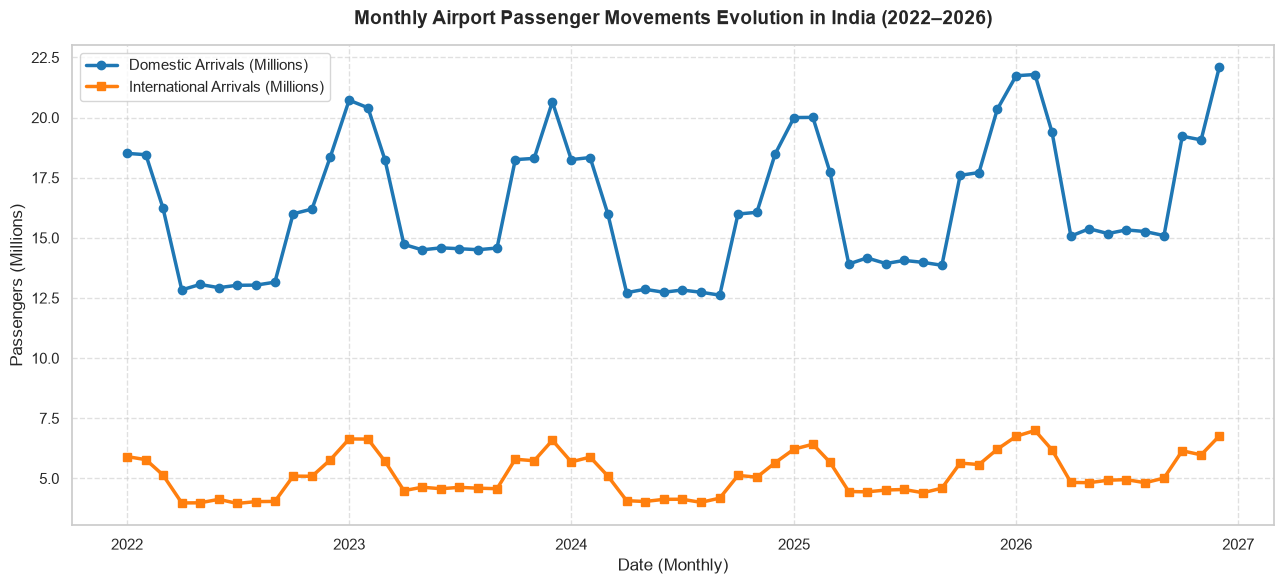

In [133]:
plt.figure(figsize=(13, 6))
monthly_traffic = df_airport_traffic.groupby('Date')[
    ['Domestic_Passengers_Arrival', 'International_Passengers_Arrival']
].sum() / 1e6

plt.plot(monthly_traffic.index, monthly_traffic['Domestic_Passengers_Arrival'], marker='o', linewidth=2.5, label='Domestic Arrivals (Millions)', color='#1f77b4')
plt.plot(monthly_traffic.index, monthly_traffic['International_Passengers_Arrival'], marker='s', linewidth=2.5, label='International Arrivals (Millions)', color='#ff7f0e')

plt.title('Monthly Airport Passenger Movements Evolution in India (2022–2026)', fontsize=14, weight='bold', pad=15)
plt.xlabel('Date (Monthly)', fontsize=12)
plt.ylabel('Passengers (Millions)', fontsize=12)
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


### 8.2 Chart 2: Inbound Spend vs. Overall Experience Score (2023–2026)


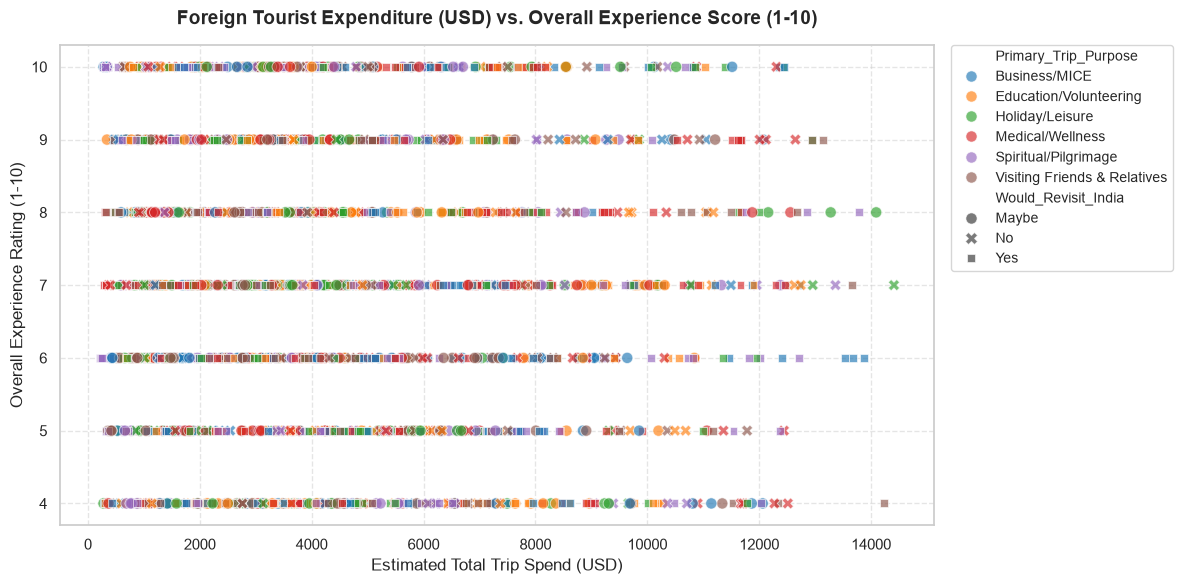

In [134]:
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df_inbound_survey,
    x='Estimated_Total_Spend_USD',
    y='Overall_Experience_Score_1to10',
    hue='Primary_Trip_Purpose',
    style='Would_Revisit_India',
    palette='tab10',
    alpha=0.65,
    s=65
)
plt.title('Foreign Tourist Expenditure (USD) vs. Overall Experience Score (1-10)', fontsize=14, weight='bold', pad=15)
plt.xlabel('Estimated Total Trip Spend (USD)', fontsize=12)
plt.ylabel('Overall Experience Rating (1-10)', fontsize=12)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10, borderaxespad=0)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### 8.3 Chart 3: Top 10 States by Projected Total Tourist Footfall (2026)


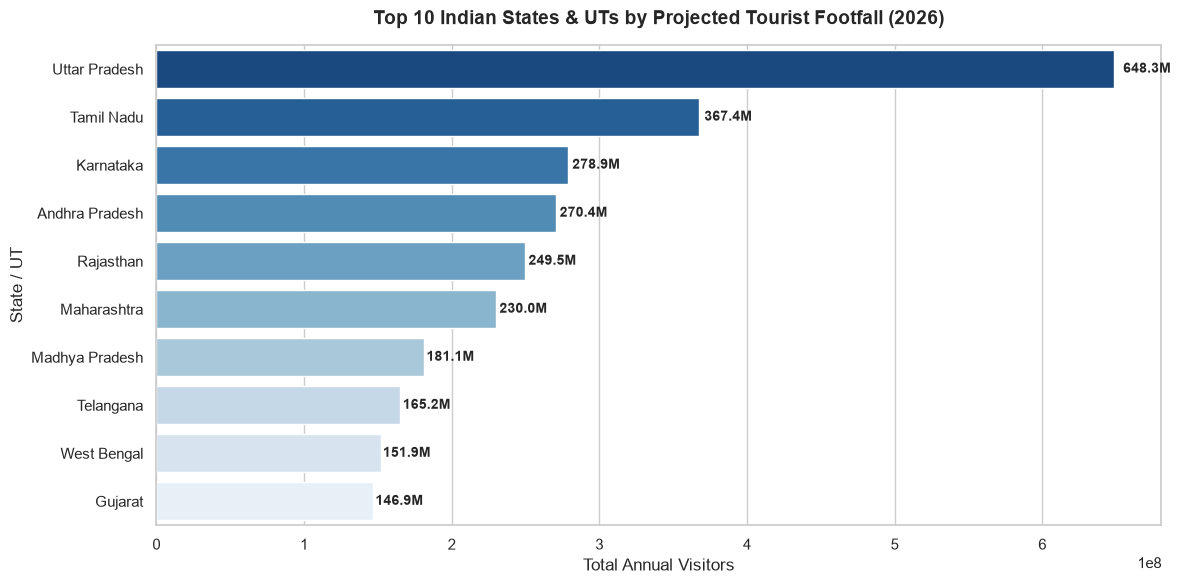

In [135]:
plt.figure(figsize=(12, 6))
top_states_2026 = df_state_ut_summary.sort_values('Total_Visitors_2026', ascending=False).head(10)

sns.barplot(
    data=top_states_2026,
    x='Total_Visitors_2026',
    y='State_UT',
    hue='State_UT',
    palette='Blues_r',
    legend=False
)
plt.title('Top 10 Indian States & UTs by Projected Tourist Footfall (2026)', fontsize=14, weight='bold', pad=15)
plt.xlabel('Total Annual Visitors', fontsize=12)
plt.ylabel('State / UT', fontsize=12)
for index, value in enumerate(top_states_2026['Total_Visitors_2026']):
    plt.text(value * 1.01, index, f'{value/1e6:.1f}M', va='center', fontsize=10, weight='semibold')
plt.tight_layout()
plt.show()


### 8.4 Chart 4: District Footfall & Tourism Infrastructure Correlation Matrix


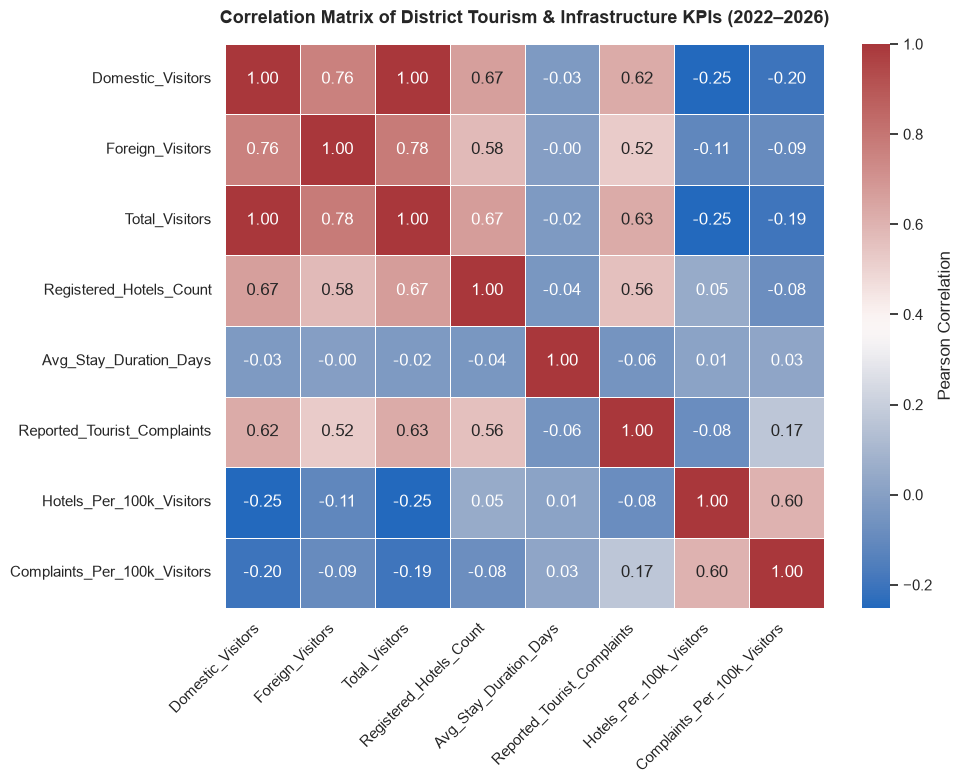

In [136]:
plt.figure(figsize=(10, 8))
corr_cols = [
    'Domestic_Visitors', 'Foreign_Visitors', 'Total_Visitors',
    'Registered_Hotels_Count', 'Avg_Stay_Duration_Days', 'Reported_Tourist_Complaints',
    'Hotels_Per_100k_Visitors', 'Complaints_Per_100k_Visitors'
]
corr_matrix = df_district_footfall[corr_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='vlag', fmt='.2f', linewidths=0.5, cbar_kws={'label': 'Pearson Correlation'})
plt.title('Correlation Matrix of District Tourism & Infrastructure KPIs (2022–2026)', fontsize=13, weight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### 8.5 Chart 5: Room Tariff Distribution by Accommodation Category


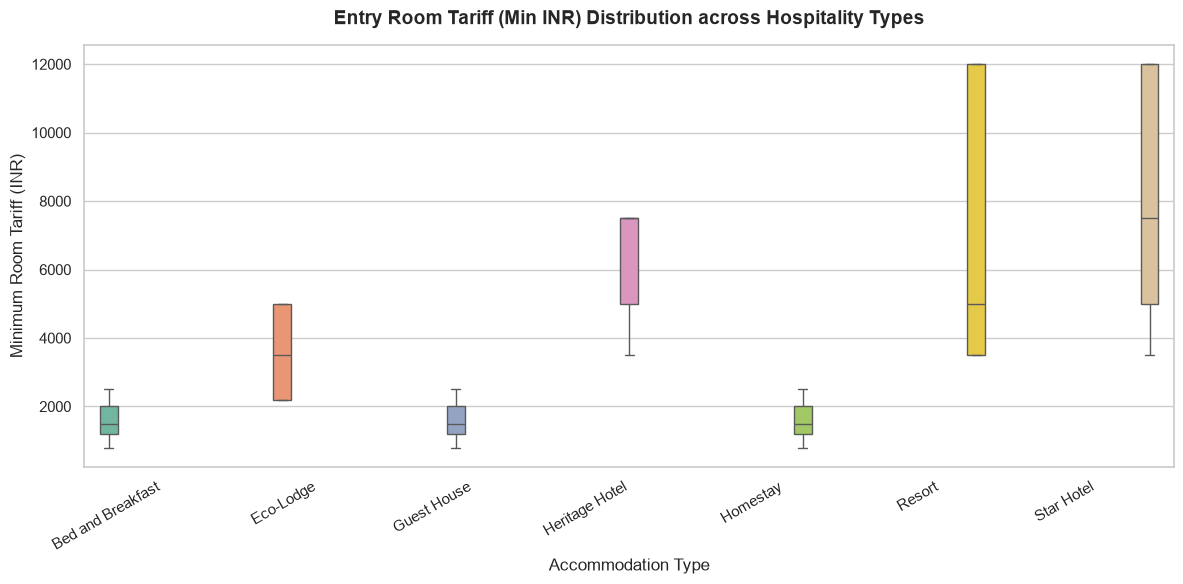

In [137]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_nidhi_hospitality,
    x='Accommodation_Type',
    y='Room_Tariff_Min_INR',
    hue='Accommodation_Type',
    palette='Set2',
    legend=False,
    showfliers=False  # Hide extreme outliers for clean distribution visualization
)
plt.title('Entry Room Tariff (Min INR) Distribution across Hospitality Types', fontsize=14, weight='bold', pad=15)
plt.xlabel('Accommodation Type', fontsize=12)
plt.ylabel('Minimum Room Tariff (INR)', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()
